## Kliuev Dmitrii fourth dz

# Flight Delays Report for the Ministry of Transport

## Цель

Изучить природу и характеристики задержек авиарейсов, выявить проблемные зоны и факторы, влияющие на пунктуальность, для предоставления рекомендаций Министерству транспорта.

### Содержимое проекта
 
1. [Загрузка данных и знакомство с ними.](#part1)
2. [Предобработка данных.](#part2)
3. [Исследовательский анализ данных.](#part3)
4. [Итог.](#part4)
 


## 1. Загрузка данных и знакомство с ними
 
 <a id='part1'></a>

In [1]:
#Подключение библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Загрузка данных из файлов
flights = pd.read_csv('flights.csv', low_memory=False)

#Зададим правила вывода
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:,.2f}'.format

In [3]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

In [4]:
print('\nПропущенные значения:')
missing_df = pd.DataFrame({
    'Количество': flights.isnull().sum(),
    'Доля': (flights.isnull().sum() / len(flights)).round(3)
})
print(missing_df.sort_values(by='Доля', ascending=False))


Пропущенные значения:
                     Количество  Доля
CANCELLATION_REASON     5729195  0.98
WEATHER_DELAY           4755640  0.82
LATE_AIRCRAFT_DELAY     4755640  0.82
AIRLINE_DELAY           4755640  0.82
SECURITY_DELAY          4755640  0.82
AIR_SYSTEM_DELAY        4755640  0.82
AIR_TIME                 105071  0.02
ARRIVAL_DELAY            105071  0.02
ELAPSED_TIME             105071  0.02
WHEELS_ON                 92513  0.02
TAXI_IN                   92513  0.02
ARRIVAL_TIME              92513  0.02
DEPARTURE_DELAY           86153  0.01
TAXI_OUT                  89047  0.01
WHEELS_OFF                89047  0.01
DEPARTURE_TIME            86153  0.01
TAIL_NUMBER               14721  0.00
SCHEDULED_DEPARTURE           0  0.00
CANCELLED                     0  0.00
DAY                           0  0.00
DAY_OF_WEEK                   0  0.00
AIRLINE                       0  0.00
FLIGHT_NUMBER                 0  0.00
SCHEDULED_ARRIVAL             0  0.00
DIVERTED                   

In [5]:
flights.head(10)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,"2,354.00",-11.00,21.00,15.00,205.00,194.00,169.00,1448,404.00,4.00,430,408.00,-22.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.00,-8.00,12.00,14.00,280.00,279.00,263.00,2330,737.00,4.00,750,741.00,-9.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.00,-2.00,16.00,34.00,286.00,293.00,266.00,2296,800.00,11.00,806,811.00,5.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.00,-5.00,15.00,30.00,285.00,281.00,258.00,2342,748.00,8.00,805,756.00,-9.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.00,-1.00,11.00,35.00,235.00,215.00,199.00,1448,254.00,5.00,320,259.00,-21.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5,2015,1,1,4,DL,806,N3730B,SFO,MSP,25,20.00,-5.00,18.00,38.00,217.00,230.00,206.00,1589,604.00,6.00,602,610.00,8.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
6,2015,1,1,4,NK,612,N635NK,LAS,MSP,25,19.00,-6.00,11.00,30.00,181.00,170.00,154.00,1299,504.00,5.00,526,509.00,-17.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
7,2015,1,1,4,US,2013,N584UW,LAX,CLT,30,44.00,14.00,13.00,57.00,273.00,249.00,228.00,2125,745.00,8.00,803,753.00,-10.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
8,2015,1,1,4,AA,1112,N3LAAA,SFO,DFW,30,19.00,-11.00,17.00,36.00,195.00,193.00,173.00,1464,529.00,3.00,545,532.00,-13.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
9,2015,1,1,4,DL,1173,N826DN,LAS,ATL,30,33.00,3.00,12.00,45.00,221.00,203.00,186.00,1747,651.00,5.00,711,656.00,-15.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN


### Промежуточный вывод по исходному состоянию данных

На текущем этапе работы с данными можно заметить следующее:

В данных много пропусков, особенно в столбцах, связанных с задержками и отменами рейсов, что скорее всего связано с тем, что у большинства рейсов нет происшествий, и поэтому значения в этих столбцах у них пропущены;

Типы данных некоторых столбцов не соответствуют содержащися в них данным, требуется некоторые правки - это относится к столбцам 'CANCELLED' и 'DIVERTED', их стоит привести к типу 'bool';

## 2. Предобработка данных
 
 <a id='part2'></a>

### Обработка пропусков

In [6]:
#Создание стобца с датой для удобства
flights['DATE'] = pd.to_datetime(flights[['YEAR', 'MONTH', 'DAY']])

In [7]:
#Заполнение пропусков в столбце 'TAIL_NUMBER' индикаторным значением
flights['TAIL_NUMBER'] = flights['TAIL_NUMBER'].fillna('no_tail')

In [8]:
#Заполнение пропусков в столбце 'CANCELLATION_REASON' индикаторным значением
flights['CANCELLATION_REASON'] = flights['CANCELLATION_REASON'].fillna('not_cancelled')

Проверим, перекаются ли пропуски по столбцам 'LATE_AIRCRAFT_DELAY', 'AIRLINE_DELAY', 'AIR_SYSTEM_DELAY', 'WEATHER_DELAY' и 'SECURITY_DELAY':

In [9]:
#Расчет доли пропущенных значений в каждом из столбцов датасета, у которых есть пропуски в столбце 'LATE_AIRCRAFT_DELAY'
print('Доля пропущенных значений:')
mis_values_visit = flights[flights['LATE_AIRCRAFT_DELAY'].isnull()].isnull().sum().to_frame('missing_values')
mis_values_visit['Доля'] = round(flights[flights['LATE_AIRCRAFT_DELAY'].isnull()].isna().mean(),2)
print(mis_values_visit.sort_values(by='Доля', ascending=False))

Доля пропущенных значений:
                     missing_values  Доля
WEATHER_DELAY               4755640  1.00
LATE_AIRCRAFT_DELAY         4755640  1.00
AIRLINE_DELAY               4755640  1.00
SECURITY_DELAY              4755640  1.00
AIR_SYSTEM_DELAY            4755640  1.00
AIR_TIME                     105071  0.02
TAXI_OUT                      89047  0.02
ARRIVAL_TIME                  92513  0.02
ELAPSED_TIME                 105071  0.02
ARRIVAL_DELAY                105071  0.02
WHEELS_OFF                    89047  0.02
WHEELS_ON                     92513  0.02
DEPARTURE_DELAY               86153  0.02
DEPARTURE_TIME                86153  0.02
TAXI_IN                       92513  0.02
CANCELLED                         0  0.00
CANCELLATION_REASON               0  0.00
SCHEDULED_ARRIVAL                 0  0.00
DIVERTED                          0  0.00
YEAR                              0  0.00
DISTANCE                          0  0.00
MONTH                             0  0.00
SCHEDUL

Cовпали. Пропущенные значения в этих столбцах означают, что рейс не задерживался, т.е. либо был отменен, либо прошёл нормально. Пропуски в этих столбцах стоит оставить без изменений, так как их заполнение может повлиять на результаты исследования. На текщий момент картина следующая:

Пропуски в оставшихся столбцах часто совпадают по строкам и касаются временных меток рейса (вылет, взлёт и пр.), что, скорее всего, связано с отсутствием данных от систем отслеживания. Заполнять их необязательно. При необходимости анализа этих характеристик столбцы с пропусками можно будет удалить из-за их малой доли.

In [10]:
flights.head(15)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,DATE
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,"2,354.00",-11.00,21.00,15.00,205.00,194.00,169.00,1448,404.00,4.00,430,408.00,-22.00,0,0,not_cancelled,NaN,NaN,NaN,NaN,NaN,2015-01-01
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.00,-8.00,12.00,14.00,280.00,279.00,263.00,2330,737.00,4.00,750,741.00,-9.00,0,0,not_cancelled,NaN,NaN,NaN,NaN,NaN,2015-01-01
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.00,-2.00,16.00,34.00,286.00,293.00,266.00,2296,800.00,11.00,806,811.00,5.00,0,0,not_cancelled,NaN,NaN,NaN,NaN,NaN,2015-01-01
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.00,-5.00,15.00,30.00,285.00,281.00,258.00,2342,748.00,8.00,805,756.00,-9.00,0,0,not_cancelled,NaN,NaN,NaN,NaN,NaN,2015-01-01
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.00,-1.00,11.00,35.00,235.00,215.00,199.00,1448,254.00,5.00,320,259.00,-21.00,0,0,not_cancelled,NaN,NaN,NaN,NaN,NaN,2015-01-01
5,2015,1,1,4,DL,806,N3730B,SFO,MSP,25,20.00,-5.00,18.00,38.00,217.00,230.00,206.00,1589,604.00,6.00,602,610.00,8.00,0,0,not_cancelled,NaN,NaN,NaN,NaN,NaN,2015-01-01
6,2015,1,1,4,NK,612,N635NK,LAS,MSP,25,19.00,-6.00,11.00,30.00,181.00,170.00,154.00,1299,504.00,5.00,526,509.00,-17.00,0,0,not_cancelled,NaN,NaN,NaN,NaN,NaN,2015-01-01
7,2015,1,1,4,US,2013,N584UW,LAX,CLT,30,44.00,14.00,13.00,57.00,273.00,249.00,228.00,2125,745.00,8.00,803,753.00,-10.00,0,0,not_cancelled,NaN,NaN,NaN,NaN,NaN,2015-01-01
8,2015,1,1,4,AA,1112,N3LAAA,SFO,DFW,30,19.00,-11.00,17.00,36.00,195.00,193.00,173.00,1464,529.00,3.00,545,532.00,-13.00,0,0,not_cancelled,NaN,NaN,NaN,NaN,NaN,2015-01-01
9,2015,1,1,4,DL,1173,N826DN,LAS,ATL,30,33.00,3.00,12.00,45.00,221.00,203.00,186.00,1747,651.00,5.00,711,656.00,-15.00,0,0,not_cancelled,NaN,NaN,NaN,NaN,NaN,2015-01-01


### Приведение стобцов к правильному типу данных

In [11]:
#Приведение столбцов к нужному типу
flights['DIVERTED'] = flights['DIVERTED'].astype(bool)
flights['CANCELLED'] = flights['CANCELLED'].astype(bool)

In [12]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 32 columns):
 #   Column               Dtype         
---  ------               -----         
 0   YEAR                 int64         
 1   MONTH                int64         
 2   DAY                  int64         
 3   DAY_OF_WEEK          int64         
 4   AIRLINE              object        
 5   FLIGHT_NUMBER        int64         
 6   TAIL_NUMBER          object        
 7   ORIGIN_AIRPORT       object        
 8   DESTINATION_AIRPORT  object        
 9   SCHEDULED_DEPARTURE  int64         
 10  DEPARTURE_TIME       float64       
 11  DEPARTURE_DELAY      float64       
 12  TAXI_OUT             float64       
 13  WHEELS_OFF           float64       
 14  SCHEDULED_TIME       float64       
 15  ELAPSED_TIME         float64       
 16  AIR_TIME             float64       
 17  DISTANCE             int64         
 18  WHEELS_ON            float64       
 19  TAXI_IN              

На самом деле еще у многих столбцов можно сократить размерность типа данных для экономиии памяти, но будем считать,что у нас нет проблем с памятью

### Обработка дубликатов

In [13]:
# Сколько всего дубликатов (полностью совпадающих строк)
print(f"Всего дубликатов строк: {flights.duplicated().sum()}")

Всего дубликатов строк: 0


### Промежуточный вывод после предобработки

На текущем этапе работы с данными можно заметить следующее:

- Был создан столбец DATE для удобства
- Пропуски в датасете были обработаны - в столбцах 'TAIL_NUMBER' и 'CANCELLATION_REASON' они были заполнены индикаторными значениями, а в остальных были оставлены неизменными;
- В датафрейме нее явных дубликатов;
- Столбцы 'DIVERTED' и 'CANCELLED' были приведены к типу данных 'bool'.

## 3. Исследовательский анализ данных
 
 <a id='part3'></a>

### Анализ задержек по дням недели

Для начала проанализируем как связана средняя задержка в минутах с количеством рейсов по дням:

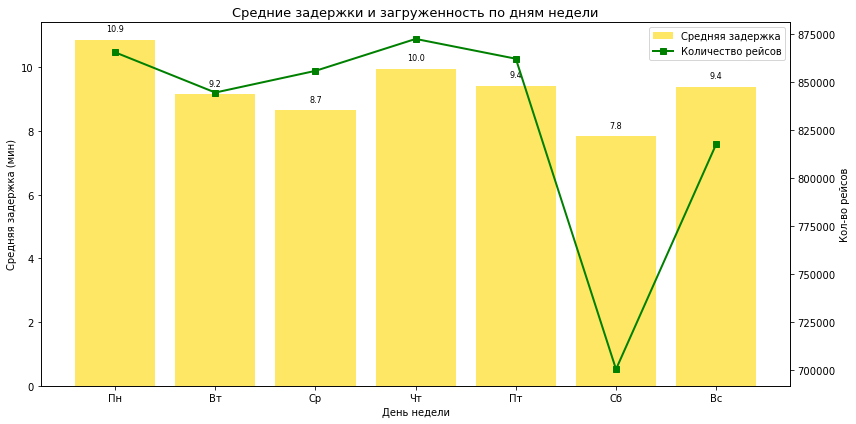

In [14]:
# Названия дней недели
day_names = {1: 'Пн', 2: 'Вт', 3: 'Ср', 4: 'Чт', 5: 'Пт', 6: 'Сб', 7: 'Вс'}

# Агрегация по дням
delay_by_day = flights.groupby('DAY_OF_WEEK')['DEPARTURE_DELAY'].mean().round(2)
flights_count = flights.groupby('DAY_OF_WEEK').size()

# График с двумя осями
fig, ax = plt.subplots(figsize=(12, 6))

# Столбцы для задержек
bars = ax.bar(delay_by_day.index, delay_by_day.values, color='gold', alpha=0.6, label='Средняя задержка')
ax.set_xlabel('День недели')
ax.set_ylabel('Средняя задержка (мин)', color='black')
ax.tick_params(axis='y', labelcolor='black')
ax.set_xticks(range(1, 8))
ax.set_xticklabels([day_names[i] for i in range(1, 8)])

# Линия для количества рейсов
ax2 = ax.twinx()
line = ax2.plot(flights_count.index, flights_count.values, color='green', marker='s', linestyle='-', linewidth=2, label='Количество рейсов')
ax2.set_ylabel('Кол-во рейсов', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Подписи на столбцах
for x, y in zip(delay_by_day.index, delay_by_day.values):
    ax.text(x, y + 0.2, f'{y:.1f}', ha='center', va='bottom', fontsize=8)

# Объединённая легенда 
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

plt.title('Средние задержки и загруженность по дням недели', fontsize=13)
plt.tight_layout()
plt.show()

### Промежуточный вывод
Наибольшие средние задержки вылетов наблюдаются в дни с самым интенсивным трафиком. Это свидетельствует о том, что пропускная способность аэропортов и служб недостаточна для пиковых нагрузок, что приводит к системным сбоям в расписании.

### Анализ сравнения утренних и вечерних рейсов

Проанализируем, как связано с задержкой время вылета - утром или вечером:

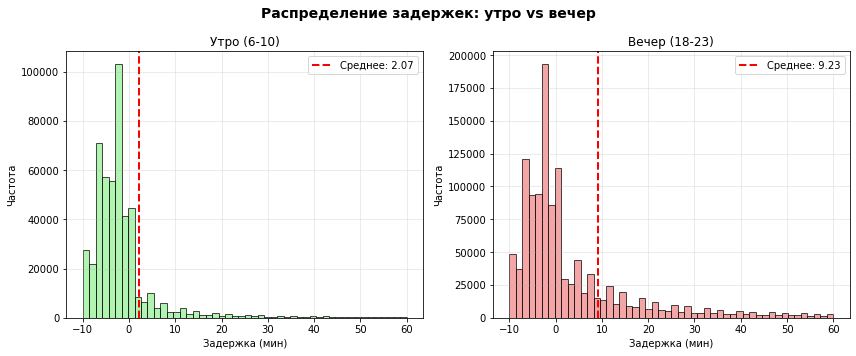


Статистика по задержкам:
               mean   std    min      max
TIME_CAT                                 
Вечер (18-23)  9.23 36.28 -55.00 1,609.00
Утро (6-10)    2.07 34.41 -37.00 1,587.00


In [15]:
# Создание категории времени суток
def time_of_day(hour):
    if 6 <= hour <= 10:
        return 'Утро (6-10)'
    elif 18 <= hour <= 23:
        return 'Вечер (18-23)'
    else:
        return 'Другое'

# Создаем копию массива для построения графика
df2 = flights.copy()

# Предполагаем, что час извлечен из SCHEDULED_DEPARTURE
df2['HOUR'] = df2['SCHEDULED_DEPARTURE'] // 60
df2['TIME_CAT'] = df2['HOUR'].apply(time_of_day)

# Фильтрация только для утра и вечера
time_filtered = df2[df2['TIME_CAT'].isin(['Утро (6-10)', 'Вечер (18-23)'])]

# Удаление пропусков в задержках
time_filtered = time_filtered.dropna(subset=['DEPARTURE_DELAY'])

# Построение гистограмм
plt.figure(figsize=(12, 5))

# Утро
plt.subplot(1, 2, 1)
morning_data = time_filtered[time_filtered['TIME_CAT'] == 'Утро (6-10)']['DEPARTURE_DELAY']
plt.hist(morning_data, bins=50, alpha=0.7, color='lightgreen', edgecolor='black', range=(-10, 60))
plt.axvline(morning_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {morning_data.mean():.2f}')
plt.xlabel('Задержка (мин)')
plt.ylabel('Частота')
plt.title('Утро (6-10)')
plt.legend()
plt.grid(alpha=0.3)

# Вечер
plt.subplot(1, 2, 2)
evening_data = time_filtered[time_filtered['TIME_CAT'] == 'Вечер (18-23)']['DEPARTURE_DELAY']
plt.hist(evening_data, bins=50, alpha=0.7, color='lightcoral', edgecolor='black', range=(-10, 60))
plt.axvline(evening_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {evening_data.mean():.2f}')
plt.xlabel('Задержка (мин)')
plt.ylabel('Частота')
plt.title('Вечер (18-23)')
plt.legend()
plt.grid(alpha=0.3)

plt.suptitle('Распределение задержек: утро vs вечер', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Вывод статистики
print("\nСтатистика по задержкам:")
print(time_filtered.groupby('TIME_CAT')['DEPARTURE_DELAY'].describe()[['mean', 'std', 'min', 'max']].round(2))

### Промежуточный вывод

Анализ распределения задержек выявил ярко выраженную зависимость от времени суток: вечерние рейсы (18–23) опаздывают в среднем **в 4,5 раза чаще утренних** (9,2 мин против 2,1 мин), хотя разброс значений сопоставим. 

Примечательно, что утром основная масса рейсов укладывается в график или даже вылетает с опережением (отрицательные задержки — это норма, рейс раньше расписания), тогда как вечером распределение смещается вправо: накапливаются задержки 10–30 минут и появляются аномально долгие опоздания (до суток). 

Это указывает на **эффект домино**: дневные сбои тянутся за вечерними рейсами, и инфраструктура к вечеру уже не справляется с нагрузкой. Именно вечернее «окно» требует первоочередной оптимизации.

### Анализ влияния дальности перелёта на задержки

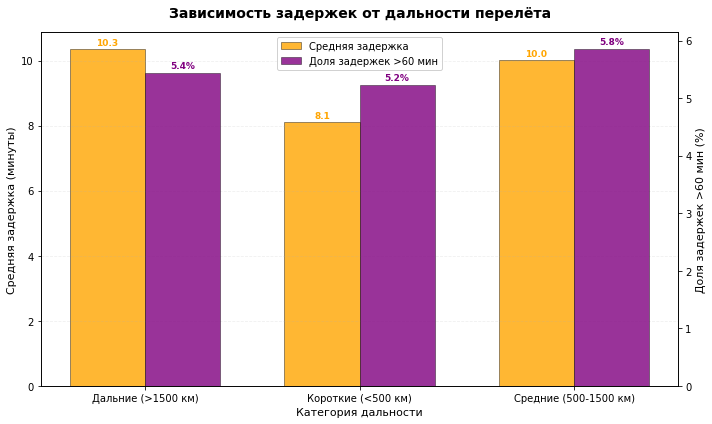

In [16]:
# Создание категорий дальности
def distance_category(dist):
    if dist < 500:
        return 'Короткие (<500 км)'
    elif dist < 1500:
        return 'Средние (500-1500 км)'
    else:
        return 'Дальние (>1500 км)'

# Создаем копию массива для построения графика
df2 = flights.copy()
df2['DISTANCE_CAT'] = df2['DISTANCE'].apply(distance_category)

# Расчет метрик для каждой категории
distance_stats = df2.groupby('DISTANCE_CAT').agg({
    'DEPARTURE_DELAY': ['mean', lambda x: (x > 60).mean() * 100]
}).round(2)
distance_stats.columns = ['Средняя задержка (мин)', 'Доля задержек >60 мин (%)']
distance_stats = distance_stats.reset_index()

# Создание групповой столбчатой диаграммы
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(distance_stats['DISTANCE_CAT']))
width = 0.35

# Столбцы для средней задержки
bars1 = ax.bar(x - width/2, distance_stats['Средняя задержка (мин)'], width, 
               label='Средняя задержка', color='orange', alpha=0.8, edgecolor='black', linewidth=0.5)

# Вторая ось для доли критических задержек
ax2 = ax.twinx()
bars2 = ax2.bar(x + width/2, distance_stats['Доля задержек >60 мин (%)'], width, 
                label='Доля задержек >60 мин', color='purple', alpha=0.8, edgecolor='black', linewidth=0.5)

# Настройка графика
ax.set_xlabel('Категория дальности', fontsize=11, color='black')
ax.set_ylabel('Средняя задержка (минуты)', fontsize=11, color='black')
ax2.set_ylabel('Доля задержек >60 мин (%)', fontsize=11, color='black')

ax.set_xticks(x)
ax.set_xticklabels(distance_stats['DISTANCE_CAT'], fontsize=10, color='black')
ax.tick_params(axis='y', labelcolor='black')
ax2.tick_params(axis='y', labelcolor='black')


ax.grid(axis='y', alpha=0.2, linestyle='--')

# Подписи значений на столбцах
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.05, f'{height:.1f}', 
            ha='center', va='bottom', fontsize=9, color='orange', fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + 0.05, f'{height:.1f}%', 
             ha='center', va='bottom', fontsize=9, color='purple', fontweight='bold')

plt.title('Зависимость задержек от дальности перелёта', fontsize=14, fontweight='bold', pad=15)

# Объединённая легенда
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()

### Промежуточный вывод 
Наиболее проблемными с точки зрения пунктуальности являются средние и дальние рейсы. Именно они требуют первоочередного внимания при планировании мер по сокращению задержек. Короткие рейсы, напротив, демонстрируют лучшие показатели как по средней задержке, так и по доле серьёзных опозданий.

### Анализ ежемесячной динамики

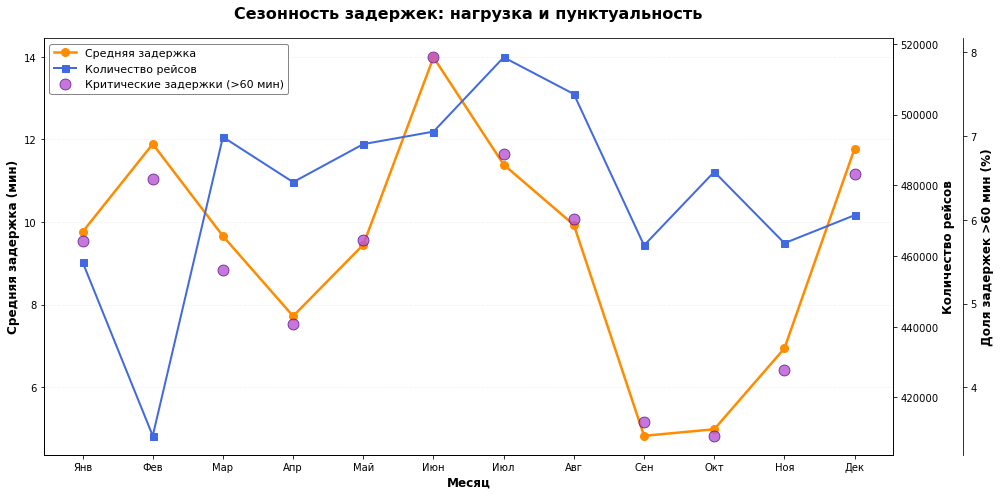

In [17]:
# Словарь для названий месяцев
months_map = {1: 'Янв', 2: 'Фев', 3: 'Мар', 4: 'Апр', 5: 'Май', 6: 'Июн',
              7: 'Июл', 8: 'Авг', 9: 'Сен', 10: 'Окт', 11: 'Ноя', 12: 'Дек'}

# Расчет метрик по месяцам
monthly_stats = flights.groupby('MONTH').agg(
    avg_delay=('DEPARTURE_DELAY', 'mean'),
    total_flights=('DEPARTURE_DELAY', 'count'),
    severe_delay_rate=('DEPARTURE_DELAY', lambda x: (x > 60).mean() * 100)
).round(2)

# Создание фигуры с двумя осями
fig, ax1 = plt.subplots(figsize=(14, 7))

# Линия средних задержек
ax1.set_xlabel('Месяц', fontsize=12, fontweight='semibold', color='black')
ax1.set_ylabel('Средняя задержка (мин)', color='black', fontsize=12, fontweight='semibold')
line1 = ax1.plot(monthly_stats.index, monthly_stats['avg_delay'], 
                 color='darkorange', marker='o', markersize=8, 
                 linewidth=2.5, label='Средняя задержка')
ax1.tick_params(axis='y', labelcolor='black')  
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels([months_map[i] for i in range(1, 13)], fontsize=10, color='black')  
ax1.grid(axis='y', alpha=0.15, linestyle='--')

# Вторая ось для количества рейсов
ax2 = ax1.twinx()
ax2.set_ylabel('Количество рейсов', color='black', fontsize=12, fontweight='semibold')
line2 = ax2.plot(monthly_stats.index, monthly_stats['total_flights'], 
                 color='royalblue', marker='s', markersize=7, 
                 linewidth=2, label='Количество рейсов')
ax2.tick_params(axis='y', labelcolor='black') 

# Третья ось для доли критических задержек
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 70))
ax3.set_ylabel('Доля задержек >60 мин (%)', color='black', fontsize=12, fontweight='semibold')
scatter = ax3.scatter(monthly_stats.index, monthly_stats['severe_delay_rate'], 
                      color='mediumorchid', s=120, alpha=0.8, 
                      edgecolor='indigo', linewidth=0.8,
                      label='Критические задержки (>60 мин)', zorder=5)
ax3.tick_params(axis='y', labelcolor='black')  

# Заголовок
plt.title('Сезонность задержек: нагрузка и пунктуальность', 
          fontsize=16, fontweight='bold', pad=20)

# Объединение легенд
lines = line1 + line2 + [scatter]
labels = [l.get_label() for l in lines]
legend = ax1.legend(lines, labels, loc='upper left', fontsize=11, 
                    framealpha=0.95, edgecolor='gray', fancybox=True)
legend.set_zorder(10)

# Убираем лишние рамки у дополнительных осей
ax3.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

### Промежуточный вывод

Анализ сезонной динамики показывает устойчивую обратную зависимость между загруженностью аэропортов и пунктуальностью рейсов. В летние месяцы (июнь–август), на которые приходится пик авиаперевозок (до 520 000 рейсов), наблюдается максимальный уровень задержек: средняя задержка достигает 10–14 минут, а доля критических опозданий (более 60 минут) колеблется в районе 5,8–6,6%. 

Зимой, при спаде трафика, ситуация улучшается: средняя задержка снижается, а доля серьёзных опозданий падает. 

Именно высокая летняя нагрузка провоцирует рост задержек. Это указывает на недостаточную пропускную способность инфраструктуры в пиковый сезон и необходимость перераспределять ресурсы (персонал, наземное обслуживание) под увеличивающийся пассажиропоток.

### Анализ проблемных маршрутов

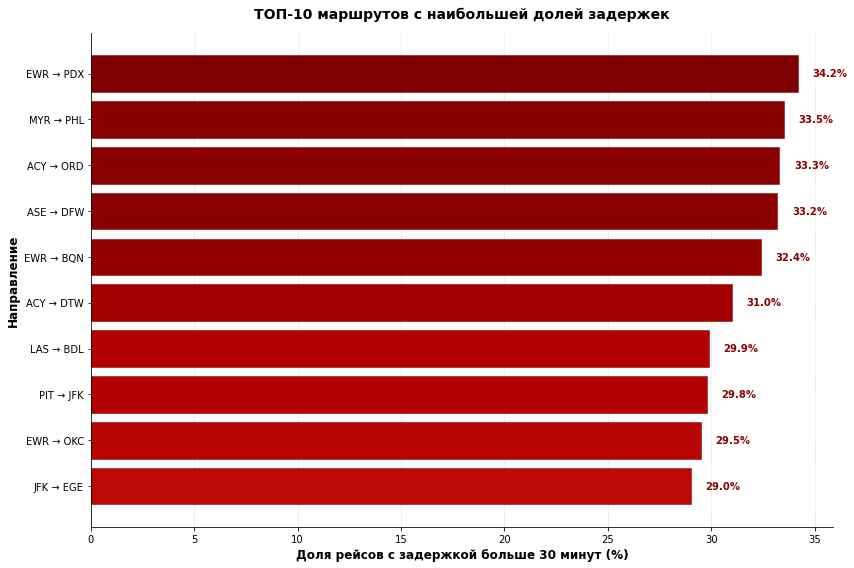

In [18]:
df2 = flights.copy()

# Создание колонки с направлением
df2['ROUTE'] = df2['ORIGIN_AIRPORT'] + ' → ' + df2['DESTINATION_AIRPORT']

# Расчет доли задержанных рейсов (>30 минут) для каждого направления
route_delays = df2.groupby('ROUTE').agg(
    total_flights=('DEPARTURE_DELAY', 'count'),
    delayed_flights=('DEPARTURE_DELAY', lambda x: (x > 30).sum())
)
route_delays['delay_percent'] = (route_delays['delayed_flights'] / route_delays['total_flights'] * 100).round(1)

# Фильтрация направлений с достаточным количеством рейсов (минимум 100 за год)
significant_routes = route_delays[route_delays['total_flights'] >= 100]

# Выбор топ-10 худших по доле задержек
top_problematic = significant_routes.nlargest(10, 'delay_percent').sort_values('delay_percent')

# Построение горизонтальной столбчатой диаграммы
plt.figure(figsize=(12, 8))

# Используем градиент
colors = plt.cm.OrRd(top_problematic['delay_percent'] / max(top_problematic['delay_percent']))

bars = plt.barh(top_problematic.index, top_problematic['delay_percent'], 
                color=colors, edgecolor='maroon', linewidth=0.5)

# Настройка подписей
plt.xlabel('Доля рейсов с задержкой больше 30 минут (%)', fontsize=12, fontweight='semibold')
plt.ylabel('Направление', fontsize=12, fontweight='semibold')
plt.title('ТОП-10 маршрутов с наибольшей долей задержек', fontsize=14, fontweight='bold', pad=15)

# Добавление значений на график (с отступом)
for i, (idx, row) in enumerate(top_problematic.iterrows()):
    plt.text(row['delay_percent'] + 0.7, i, f"{row['delay_percent']}%", 
             va='center', fontsize=10, fontweight='bold', color='darkred')

# Настройка сетки
plt.grid(axis='x', alpha=0.2, linestyle='--', color='gray')
plt.gca().set_axisbelow(True)  # Сетка под графиком

# Убираем лишние рамки
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Промежуточный вывод
Анализ проблемных маршрутов показал, что на отдельных направлениях доля задержек превышает 30% — то есть каждый третий рейс опаздывает более чем на полчаса. Обращает на себя внимание концентрация проблемных рейсов в аэропортах EWR и JFK: они фигурируют в большинстве маршрутов антирейтинга. Для выявления точных причин требуется более глубокий анализ каждого такого направления.

## 4. Итог
 
 <a id='part4'></a>


## Проделанная работа
- Загружены и предобработаны данные о 5,8 млн рейсов
- Выполнен анализ пропусков, приведены типы данных, создан столбец с датой
- Исследована динамика задержек по дням недели, времени суток, дальности перелётов, сезонам и конкретным направлениям
- Построены визуализации, иллюстрирующие ключевые зависимости

## Финальный вывод

Проведённый анализ выявил системный характер задержек, обусловленный неравномерностью нагрузки на инфраструктуру:

**По дням недели:** пиковые задержки приходятся на дни с максимальным трафиком, что указывает на неспособность аэропортов справляться с неравномерной загрузкой.

**По времени суток:** вечерние рейсы опаздывают в 4,5 раза чаще утренних (9,2 мин против 2,1 мин) из-за накопления дневных сбоев — эффект домино требует первоочередной оптимизации вечернего «окна».

**По дальности:** средние и дальние рейсы задерживаются сильнее коротких, причём доля критических опозданий (>60 мин) максимальна именно на них (до 5,8%).

**Сезонность:** летний пик перевозок (июнь–август) провоцирует рост задержек до 10–14 минут в среднем и до 6,6% критических опозданий — инфраструктура не рассчитана на такую нагрузку.

**Проблемные маршруты:** на ряде направлений задерживается каждый третий рейс. Аэропорты EWR и JFK фигурируют в большинстве таких маршрутов, что требует индивидуального разбора.

**Ключевая рекомендация:** необходима адаптация ресурсов под пиковые нагрузки — усиление наземного обслуживания в вечерние часы, в летний сезон и на проблемных направлениях, а также анализ цепочек задержек в течение дня.